# SVM Classification - New Datasets (Corrosion & Irritation)

This notebook implements Support Vector Machine (SVM) classifiers for irritation prediction on temporary datasets using descriptor-based features with Optuna hyperparameter optimization and comprehensive feature selection analysis.


## 1. Import Required Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# RDKit imports
from rdkit import Chem, RDLogger, DataStructs
from rdkit.Chem import Descriptors, AllChem, MACCSkeys, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.ML.Descriptors import MoleculeDescriptors as md

# Sklearn imports
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_score,
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

# Optimization and visualization
import shap
import optuna
from optuna.pruners import MedianPruner
from joblib import dump

# Plotting
plt.style.use("seaborn-v0_8-darkgrid")
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [ ]:
DATASETS_DIR = Path("new_datasets")
DATASETS = {
    "Corrosion_in_vitro": DATASETS_DIR / "in_vitro_corrosion.csv",
    "Irritation_in_vitro": DATASETS_DIR / "in_vitro_irritation.csv",
    "Corrosion_in_vivo": DATASETS_DIR / "in_vivo_corrosion.csv",
}

for name, path in DATASETS.items():
    df = pd.read_csv(path)
    # Display basic information about the dataset
    print(f"\n=== {name} Dataset ===")
    print("Dataset Information:")
    print(df.info())
    print("\nFirst 5 rows of the dataset:")
    print(df.head())

    # print class distribution according to the target variable
    print("\nClass Distribution:")
    print(df["target"].value_counts())

    # Check for duplicates
    duplicates = df.duplicated().sum()
    print(f"\nNumber of duplicate rows: {duplicates}")

    # Show duplicate rows if any
    if duplicates > 0:
        print("\nDuplicate rows:")
        print(df[df.duplicated()])

## 2. Utility Functions


In [2]:
def molecule_from_smiles(smiles):
    """Convert SMILES string to RDKit molecule object."""
    lg = RDLogger.logger()
    lg.setLevel(RDLogger.CRITICAL)
    try:
        molecule = Chem.MolFromSmiles(smiles, sanitize=True)
        if molecule is None:
            return None, "failed"

        clean_molecule = rdMolStandardize.LargestFragmentChooser()
        molecule = clean_molecule.choose(molecule)
        Chem.SanitizeMol(molecule)
        return molecule, "succeed"
    except Exception as e:
        return None, f"error: {e}"
    finally:
        lg.setLevel(RDLogger.INFO)


def calculate_descriptors(molecule):
    """Calculate RDKit descriptors (1D/2D) for a molecule."""
    descriptor_names = [desc for desc, _ in Descriptors._descList]
    calculator = md.MolecularDescriptorCalculator(descriptor_names)
    descriptor_values = calculator.CalcDescriptors(molecule)
    return dict(zip(descriptor_names, descriptor_values))


def bitvect_to_array(bitvect):
    """Convert RDKit bit vector into a NumPy array."""
    arr = np.zeros((bitvect.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(bitvect, arr)
    return arr


def calculate_fingerprint_families(molecule, n_bits=512, radius=2):
    """Calculate all fingerprint families used in one-by-one augmentation."""
    fps = {}

    fp_morgan = AllChem.GetMorganFingerprintAsBitVect(
        molecule, radius=radius, nBits=n_bits
    )
    fps["Morgan"] = bitvect_to_array(fp_morgan)

    fp_atompair = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(
        molecule, nBits=n_bits
    )
    fps["AtomPair"] = bitvect_to_array(fp_atompair)

    fp_torsion = rdMolDescriptors.GetHashedTopologicalTorsionFingerprintAsBitVect(
        molecule, nBits=n_bits
    )
    fps["Torsion"] = bitvect_to_array(fp_torsion)

    fp_rdk = Chem.RDKFingerprint(molecule, fpSize=n_bits)
    fps["RDK"] = bitvect_to_array(fp_rdk)

    fp_maccs = MACCSkeys.GenMACCSKeys(molecule)
    fps["MACCS"] = bitvect_to_array(fp_maccs)

    return fps


def remove_constant_bits(X_train_fp, X_test_fp):
    """Remove only train-constant fingerprint bits and apply same drop to test."""
    constant_cols = [
        col for col in X_train_fp.columns if X_train_fp[col].nunique(dropna=False) <= 1
    ]

    if constant_cols:
        X_train_fp = X_train_fp.drop(columns=constant_cols)
        X_test_fp = X_test_fp.drop(columns=constant_cols)

    return X_train_fp, X_test_fp, constant_cols


def compute_iqr_limits(df, factor=1.5):
    """Compute IQR-based outlier limits."""
    limits = {}
    for col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        if iqr == 0 or np.isnan(iqr):
            continue

        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        limits[col] = (lower, upper)
    return limits


def apply_iqr_limits(df, limits):
    """Apply IQR-based clipping to dataframe."""
    df_clipped = df.copy()
    for col, (lower, upper) in limits.items():
        df_clipped[col] = df_clipped[col].clip(lower, upper)
    return df_clipped


def remove_near_constant_features(X, threshold=0.80):
    """Remove features with near-constant values (variance < threshold)."""
    features_to_keep = []
    for col in X.columns:
        val_counts = X[col].value_counts(normalize=True)
        if val_counts.iloc[0] < threshold:
            features_to_keep.append(col)
    return X[features_to_keep]


def remove_correlated_features(X, threshold=0.90):
    """Remove highly correlated features (keep first occurrence)."""
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    return X.drop(columns=to_drop)


def clean_svm_params(best_params):
    """Clean Optuna SVM params before model construction."""
    params_clean = best_params.copy()
    if "gamma_choice" in params_clean:
        gamma_choice = params_clean.pop("gamma_choice")
        if gamma_choice != "value":
            params_clean["gamma"] = gamma_choice
        elif "gamma" not in params_clean:
            params_clean["gamma"] = "scale"

    if params_clean.get("kernel", "rbf") != "poly":
        params_clean.pop("degree", None)
        params_clean.pop("coef0", None)

    return params_clean


def evaluate_binary_classifier(model, X_test, y_test):
    """Evaluate binary classification model and return metrics/predictions."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    }
    return metrics, y_pred, y_proba


print("✓ Utility functions defined")

✓ Utility functions defined


## 3. Data Loading & Preprocessing


In [ ]:
# Configuration
DATASETS_DIR = Path("temp_datasets")
DATASETS = {
    "Corrosion": DATASETS_DIR / "in_vitro_corrosion.csv",
    "Irritation": DATASETS_DIR / "in_vitro_irritation.csv",
}

# Preprocessing parameters
SIMILARITY_THRESHOLD = 0.80  # Near-constant feature removal (descriptors only)
CORRELATION_THRESHOLD = 0.70  # Feature correlation threshold (descriptors only)
IQR_FACTOR = 1.5  # Outlier clipping factor (descriptors only)
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Fingerprint parameters
FINGERPRINT_BITS = 512
FINGERPRINT_RADIUS = 2
FINGERPRINT_FAMILIES = ["AtomPair", "Morgan", "Torsion", "RDK", "MACCS"]

# Container for processed datasets
processed_data = {}

for dataset_name, dataset_path in DATASETS.items():
    print(f"\n{'='*60}")
    print(f"Processing: {dataset_name}")
    print(f"{'='*60}")

    # Load dataset
    df = pd.read_csv(dataset_path)
    print(f"Loaded dataset shape: {df.shape}")
    print(f"Columns: {df.columns.tolist()}")

    # Remove duplicates
    initial_count = len(df)
    df = df.drop_duplicates()
    print(f"Removed {initial_count - len(df)} duplicate rows")

    # Identify SMILES and target columns (assuming standard naming)
    smiles_col = None
    target_col = None

    for col in df.columns:
        if "smiles" in col.lower() or "smi" in col.lower():
            smiles_col = col
        if "target" in col.lower() or "label" in col.lower() or "class" in col.lower():
            target_col = col

    if smiles_col is None or target_col is None:
        print("Warning: Could not auto-detect SMILES/target columns")
        print(f"Available columns: {df.columns.tolist()}")
        # Assume last column is target, first is SMILES
        smiles_col = df.columns[0]
        target_col = df.columns[-1]
        print(f"Using: SMILES={smiles_col}, Target={target_col}")

    y = df[target_col].values
    print(f"Target distribution: {np.bincount(y.astype(int))}")

    # Extract descriptors and fingerprints from SMILES
    print("\nExtracting RDKit descriptors and fingerprints...")
    descriptor_rows = []
    fingerprint_rows = {family: [] for family in FINGERPRINT_FAMILIES}
    valid_indices = []

    for idx, smiles in enumerate(df[smiles_col].astype(str)):
        molecule, state = molecule_from_smiles(smiles)
        if molecule is None:
            continue

        descriptor_rows.append(calculate_descriptors(molecule))
        fp_families = calculate_fingerprint_families(
            molecule, n_bits=FINGERPRINT_BITS, radius=FINGERPRINT_RADIUS
        )
        for family in FINGERPRINT_FAMILIES:
            fingerprint_rows[family].append(fp_families[family])
        valid_indices.append(idx)

    X_descriptors = pd.DataFrame(descriptor_rows)
    y_valid = y[valid_indices]

    print(f"Valid molecules: {len(valid_indices)}/{len(df)}")
    print(f"Descriptor matrix shape: {X_descriptors.shape}")

    # Build fingerprint dataframes with aligned indices
    fingerprint_dataframes = {}
    for family in FINGERPRINT_FAMILIES:
        family_matrix = np.vstack(fingerprint_rows[family])
        family_columns = [
            f"fp_{family.lower()}_{i}" for i in range(family_matrix.shape[1])
        ]
        fingerprint_dataframes[family] = pd.DataFrame(
            family_matrix, columns=family_columns, index=X_descriptors.index
        )

    # Train-test split (stratified) on descriptor matrix
    X_train_desc, X_test_desc, y_train, y_test = train_test_split(
        X_descriptors,
        y_valid,
        test_size=TEST_SIZE,
        stratify=y_valid,
        random_state=RANDOM_STATE,
    )
    print(f"Train size: {X_train_desc.shape[0]}, Test size: {X_test_desc.shape[0]}")

    # Fill missing values in train set (descriptors only)
    train_medians = X_train_desc.median()
    X_train_desc = X_train_desc.fillna(train_medians)
    X_test_desc = X_test_desc.fillna(train_medians)
    print("Missing values filled (train median)")

    # Remove near-constant descriptor features
    X_train_desc = remove_near_constant_features(
        X_train_desc, threshold=SIMILARITY_THRESHOLD
    )
    X_test_desc = X_test_desc[X_train_desc.columns]
    print(f"After removing near-constant descriptor features: {X_train_desc.shape}")

    # Remove correlated descriptor features
    X_train_desc = remove_correlated_features(
        X_train_desc, threshold=CORRELATION_THRESHOLD
    )
    X_test_desc = X_test_desc[X_train_desc.columns]
    print(f"After removing correlated descriptor features: {X_train_desc.shape}")

    # Clip outliers on descriptor train set
    iqr_limits = compute_iqr_limits(X_train_desc, factor=IQR_FACTOR)
    X_train_desc = apply_iqr_limits(X_train_desc, iqr_limits)
    X_test_desc = apply_iqr_limits(X_test_desc, iqr_limits)
    print(f"Descriptor outliers clipped (IQR factor={IQR_FACTOR})")

    # Scale descriptor features
    scaler = StandardScaler()
    X_train_desc = pd.DataFrame(
        scaler.fit_transform(X_train_desc),
        columns=X_train_desc.columns,
        index=X_train_desc.index,
    )
    X_test_desc = pd.DataFrame(
        scaler.transform(X_test_desc),
        columns=X_test_desc.columns,
        index=X_test_desc.index,
    )
    print("Descriptor features scaled (StandardScaler)")

    # Prepare fingerprints by family: remove only constant bits
    fp_train = {}
    fp_test = {}
    for family in FINGERPRINT_FAMILIES:
        X_train_fp = fingerprint_dataframes[family].loc[X_train_desc.index].copy()
        X_test_fp = fingerprint_dataframes[family].loc[X_test_desc.index].copy()

        X_train_fp, X_test_fp, dropped_constant_cols = remove_constant_bits(
            X_train_fp, X_test_fp
        )

        fp_train[family] = X_train_fp
        fp_test[family] = X_test_fp
        print(
            f"{family}: kept {X_train_fp.shape[1]} bits after dropping {len(dropped_constant_cols)} constant bits"
        )

    # Store processed data
    processed_data[dataset_name] = {
        "X_train": X_train_desc,
        "X_test": X_test_desc,
        "y_train": y_train,
        "y_test": y_test,
        "feature_names": X_train_desc.columns.tolist(),
        "fp_train": fp_train,
        "fp_test": fp_test,
        "best_descriptor_method": None,
    }

print(f"\n{'='*60}")
print("✓ Data preprocessing completed for all datasets")
print(f"{'='*60}")


Processing: Corrosion
Loaded dataset shape: (157, 3)
Columns: ['smiles', ' pka', 'target']
Removed 6 duplicate rows
Target distribution: [91 60]

Extracting RDKit descriptors and fingerprints...


[09:37:40] DEPRECATION WARNING: please use MorganGenerator
[09:37:40] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:40] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:40] DEPRECATION WARNING: please use MorganGenerator
[09:37:40] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:40] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:40] DEPRECATION WARNING: please use MorganGenerator
[09:37:40] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:40] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:40] DEPRECATION WARNING: please use MorganGenerator
[09:37:40] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:40] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:40] DEPRECATION WARNING: please use MorganGenerator
[09:37:40] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:40] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:40] DEPRECATION WARNING: please use Mo

Valid molecules: 151/151
Descriptor matrix shape: (151, 217)
Train size: 120, Test size: 31
Missing values filled (train median)
After removing near-constant descriptor features: (120, 104)
After removing correlated descriptor features: (120, 43)
Descriptor outliers clipped (IQR factor=1.5)
Descriptor features scaled (StandardScaler)
AtomPair: kept 435 bits after dropping 77 constant bits
Morgan: kept 384 bits after dropping 128 constant bits
Torsion: kept 267 bits after dropping 245 constant bits
RDK: kept 512 bits after dropping 0 constant bits
MACCS: kept 136 bits after dropping 31 constant bits

Processing: Irritation
Loaded dataset shape: (209, 3)
Columns: ['smiles', 'pka', 'target']
Removed 9 duplicate rows
Target distribution: [ 84 116]

Extracting RDKit descriptors and fingerprints...


[09:37:41] DEPRECATION WARNING: please use MorganGenerator
[09:37:41] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:41] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:41] DEPRECATION WARNING: please use MorganGenerator
[09:37:41] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:41] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:41] DEPRECATION WARNING: please use MorganGenerator
[09:37:41] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:41] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:41] DEPRECATION WARNING: please use MorganGenerator
[09:37:41] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:41] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:41] DEPRECATION WARNING: please use MorganGenerator
[09:37:41] DEPRECATION WARNING: please use AtomPairGenerator
[09:37:41] DEPRECATION WARNING: please use TopologicalTorsionGenerator
[09:37:41] DEPRECATION WARNING: please use Mo

Valid molecules: 200/200
Descriptor matrix shape: (200, 217)
Train size: 160, Test size: 40
Missing values filled (train median)
After removing near-constant descriptor features: (160, 104)
After removing correlated descriptor features: (160, 43)
Descriptor outliers clipped (IQR factor=1.5)
Descriptor features scaled (StandardScaler)
AtomPair: kept 410 bits after dropping 102 constant bits
Morgan: kept 404 bits after dropping 108 constant bits
Torsion: kept 236 bits after dropping 276 constant bits
RDK: kept 512 bits after dropping 0 constant bits
MACCS: kept 141 bits after dropping 26 constant bits

✓ Data preprocessing completed for all datasets


## 4. Feature Selection Analysis

Three complementary feature selection methods are applied to each dataset and evaluated via cross-validation.


In [4]:
def select_features_kbest(X_train, y_train, k_range=None):
    """KBest feature selection using F-score."""
    if k_range is None:
        k_range = list(range(5, min(51, X_train.shape[1]), 5)) + [X_train.shape[1]]

    rankings = {}
    for k in k_range:
        selector = SelectKBest(score_func=f_classif, k=min(k, X_train.shape[1]))
        selector.fit(X_train, y_train)
        rankings[k] = selector.get_support()

    # Get feature importance scores
    selector_all = SelectKBest(score_func=f_classif, k="all")
    selector_all.fit(X_train, y_train)
    feature_scores = pd.Series(selector_all.scores_, index=X_train.columns).sort_values(
        ascending=False
    )

    return feature_scores, rankings


def select_features_shap(X_train, y_train, k_range=None):
    """SHAP-based feature importance."""
    if k_range is None:
        k_range = list(range(5, min(51, X_train.shape[1]), 5)) + [X_train.shape[1]]

    # Train quick SVM for SHAP analysis
    svm_quick = SVC(
        kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE
    )
    svm_quick.fit(X_train, y_train)

    # Compute SHAP values
    explainer = shap.Explainer(lambda X: svm_quick.decision_function(X), X_train)
    shap_values = explainer(X_train)

    # Average absolute SHAP values
    shap_importance = np.abs(shap_values.values).mean(axis=0)
    feature_scores = pd.Series(shap_importance, index=X_train.columns).sort_values(
        ascending=False
    )

    rankings = {}
    for k in k_range:
        top_k = feature_scores.head(min(k, len(feature_scores))).index.tolist()
        mask = np.isin(X_train.columns, top_k)
        rankings[k] = mask

    return feature_scores, rankings


def select_features_lasso(X_train, y_train, k_range=None):
    """Lasso-based feature selection (L1 regularization)."""
    if k_range is None:
        k_range = list(range(5, min(51, X_train.shape[1]), 5)) + [X_train.shape[1]]

    # Train Lasso (logistic regression with L1)
    lasso = LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="liblinear",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )
    lasso.fit(X_train, y_train)

    # Feature importance from coefficients
    feature_scores = pd.Series(
        (
            np.abs(lasso.coef_).mean(axis=0)
            if lasso.coef_.ndim > 1
            else np.abs(lasso.coef_)
        ),
        index=X_train.columns,
    ).sort_values(ascending=False)

    rankings = {}
    for k in k_range:
        top_k = feature_scores.head(min(k, len(feature_scores))).index.tolist()
        mask = np.isin(X_train.columns, top_k)
        rankings[k] = mask

    return feature_scores, rankings


def evaluate_features_cv(X_train, y_train, rankings, k_range):
    """Evaluate feature subsets via cross-validation."""
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    results = []

    for k in k_range:
        mask = rankings.get(k, None)
        if mask is None or not mask.any():
            continue

        X_selected = X_train.loc[:, mask]

        # Light SVM for quick CV
        svm = SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale",
            probability=True,
            random_state=RANDOM_STATE,
        )

        scores = cross_validate(
            svm,
            X_selected,
            y_train,
            cv=cv,
            scoring=["accuracy", "f1", "roc_auc"],
            n_jobs=-1,
        )

        results.append(
            {
                "k": k,
                "accuracy": scores["test_accuracy"].mean(),
                "f1": scores["test_f1"].mean(),
                "roc_auc": scores["test_roc_auc"].mean(),
            }
        )

    return pd.DataFrame(results)


print("✓ Feature selection functions defined")

✓ Feature selection functions defined


## 5. Feature Selection Execution

Running feature selection for both datasets with CV performance analysis.


In [6]:
# Store feature selection results
feature_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Feature Selection: {dataset_name}")
    print(f"{'='*60}")

    X_train = data["X_train"]
    y_train = data["y_train"]

    k_range = list(range(5, min(X_train.shape[1], 51), 5)) + [X_train.shape[1]]

    results = {}

    # KBest
    print("\nRunning KBest (F-score)...")
    kbest_scores, kbest_rankings = select_features_kbest(X_train, y_train, k_range)
    kbest_cv = evaluate_features_cv(X_train, y_train, kbest_rankings, k_range)
    results["KBest"] = {
        "scores": kbest_scores,
        "rankings": kbest_rankings,
        "cv_results": kbest_cv,
    }
    print(
        f"Best KBest k={kbest_cv.loc[kbest_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={kbest_cv['roc_auc'].max():.3f}"
    )

    # SHAP
    print("\nRunning SHAP-based selection...")
    shap_scores, shap_rankings = select_features_shap(X_train, y_train, k_range)
    shap_cv = evaluate_features_cv(X_train, y_train, shap_rankings, k_range)
    results["SHAP"] = {
        "scores": shap_scores,
        "rankings": shap_rankings,
        "cv_results": shap_cv,
    }
    print(
        f"Best SHAP k={shap_cv.loc[shap_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={shap_cv['roc_auc'].max():.3f}"
    )

    # Lasso
    print("\nRunning Lasso (L1) selection...")
    lasso_scores, lasso_rankings = select_features_lasso(X_train, y_train, k_range)
    lasso_cv = evaluate_features_cv(X_train, y_train, lasso_rankings, k_range)
    results["Lasso"] = {
        "scores": lasso_scores,
        "rankings": lasso_rankings,
        "cv_results": lasso_cv,
    }
    print(
        f"Best Lasso k={lasso_cv.loc[lasso_cv['roc_auc'].idxmax(), 'k']:.0f}, ROC-AUC={lasso_cv['roc_auc'].max():.3f}"
    )

    feature_results[dataset_name] = results

print(f"\n{'='*60}")
print("✓ Feature selection completed for all methods and datasets")
print(f"{'='*60}")


Feature Selection: Corrosion

Running KBest (F-score)...
Best KBest k=5, ROC-AUC=0.866

Running SHAP-based selection...


PermutationExplainer explainer: 121it [00:31,  2.96it/s]                         


Best SHAP k=20, ROC-AUC=0.884

Running Lasso (L1) selection...
Best Lasso k=25, ROC-AUC=0.866

Feature Selection: Irritation

Running KBest (F-score)...
Best KBest k=20, ROC-AUC=0.858

Running SHAP-based selection...


PermutationExplainer explainer: 161it [00:42,  2.87it/s]                         


Best SHAP k=10, ROC-AUC=0.865

Running Lasso (L1) selection...
Best Lasso k=30, ROC-AUC=0.862

✓ Feature selection completed for all methods and datasets


## 6. Feature Selection Visualization


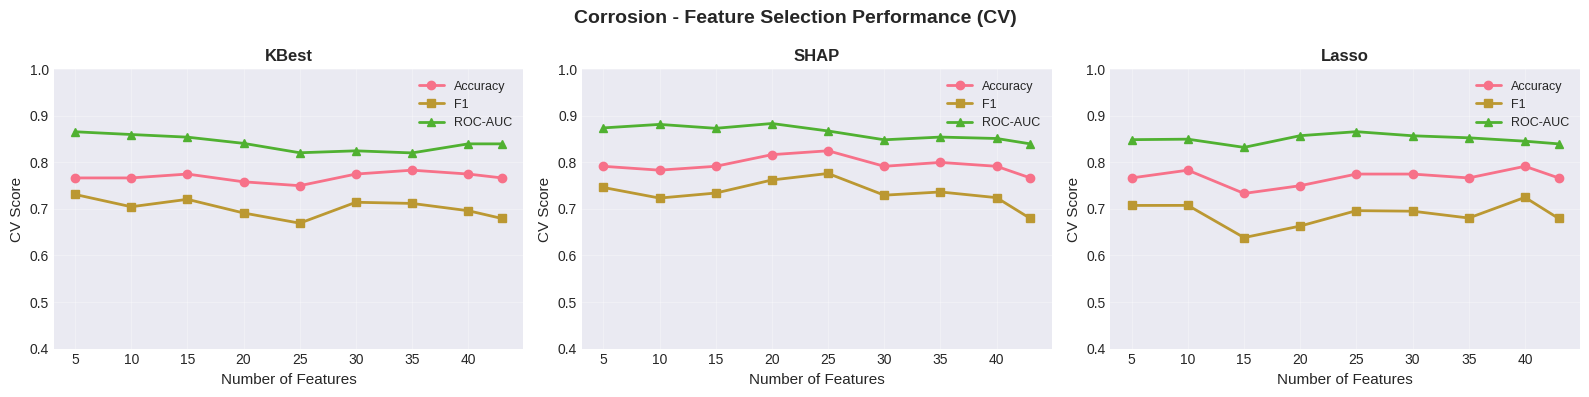

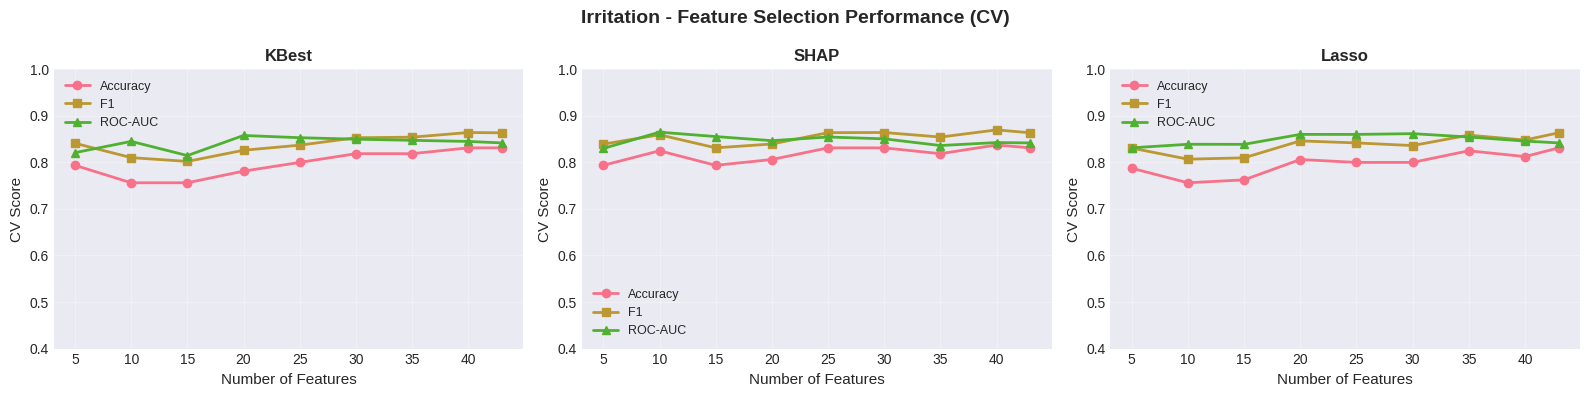

✓ Feature selection plots generated


In [10]:
for dataset_name in processed_data.keys():
    results = feature_results[dataset_name]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(
        f"{dataset_name} - Feature Selection Performance (CV)",
        fontsize=14,
        fontweight="bold",
    )

    methods = ["KBest", "SHAP", "Lasso"]
    for idx, method in enumerate(methods):
        cv_df = results[method]["cv_results"]
        ax = axes[idx]

        ax.plot(
            cv_df["k"], cv_df["accuracy"], marker="o", label="Accuracy", linewidth=2
        )
        ax.plot(cv_df["k"], cv_df["f1"], marker="s", label="F1", linewidth=2)
        ax.plot(cv_df["k"], cv_df["roc_auc"], marker="^", label="ROC-AUC", linewidth=2)

        ax.set_xlabel("Number of Features", fontsize=11)
        ax.set_ylabel("CV Score", fontsize=11)
        ax.set_title(f"{method}", fontsize=12, fontweight="bold")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_ylim([0.4, 1.0])

    plt.tight_layout()
    plt.show()

print("✓ Feature selection plots generated")

## 7. Hyperparameter Optimization with Optuna


In [5]:
def objective(trial, X_train, y_train, feature_mask):
    """Optuna objective function for SVM hyperparameter tuning."""
    # Select features
    X_selected = X_train.loc[:, feature_mask]

    # Hyperparameter suggestions
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)
    kernel = trial.suggest_categorical("kernel", ["rbf", "linear", "poly", "sigmoid"])
    gamma_choice = trial.suggest_categorical("gamma_choice", ["scale", "auto", "value"])

    if gamma_choice == "value":
        gamma = trial.suggest_float("gamma", 1e-4, 10.0, log=True)
    else:
        gamma = gamma_choice

    if kernel == "poly":
        degree = trial.suggest_int("degree", 2, 5)
        coef0 = trial.suggest_float("coef0", 0.0, 1.0)
    else:
        degree = 3
        coef0 = 0.0

    tol = trial.suggest_float("tol", 1e-5, 1e-2, log=True)
    max_iter = trial.suggest_int("max_iter", 100, 2000)
    class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])
    shrinking = trial.suggest_categorical("shrinking", [True, False])

    # Train SVM with cross-validation
    svm = SVC(
        C=C,
        kernel=kernel,
        gamma=gamma,
        degree=degree,
        coef0=coef0,
        tol=tol,
        max_iter=max_iter,
        class_weight=class_weight,
        shrinking=shrinking,
        probability=True,
        random_state=RANDOM_STATE,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(
        svm, X_selected, y_train, cv=cv, scoring="roc_auc", n_jobs=-1
    )

    # Optuna pruning
    trial.report(scores.mean(), step=0)
    if trial.should_prune():
        raise optuna.TrialPruned()

    return scores.mean()


print("✓ Optuna objective function defined")

✓ Optuna objective function defined


In [7]:
# Optimize hyperparameters for each dataset and feature selection method
optimization_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Hyperparameter Optimization: {dataset_name}")
    print(f"{'='*60}")

    X_train = data["X_train"]
    y_train = data["y_train"]

    dataset_results = {}

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\nOptimizing {method}...")

        # Get best k from CV results
        cv_results = feature_results[dataset_name][method]["cv_results"]
        best_k = cv_results.loc[cv_results["roc_auc"].idxmax(), "k"]
        best_k = int(best_k)

        # Get feature mask for best k
        feature_mask = feature_results[dataset_name][method]["rankings"][best_k]
        n_features = feature_mask.sum()

        print(f"  Best k={best_k} ({n_features} features selected)")

        # Optuna optimization
        sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
        pruner = MedianPruner(n_startup_trials=10, n_warmup_steps=5)

        study = optuna.create_study(
            direction="maximize", sampler=sampler, pruner=pruner
        )

        study.optimize(
            lambda trial: objective(trial, X_train, y_train, feature_mask),
            n_trials=100,
            show_progress_bar=True,
            n_jobs=-1,
        )

        best_trial = study.best_trial
        print(f"  Best CV ROC-AUC: {best_trial.value:.4f}")
        print(f"  Best hyperparameters: {best_trial.params}")

        dataset_results[method] = {
            "best_k": best_k,
            "feature_mask": feature_mask,
            "best_params": best_trial.params,
            "best_cv_score": best_trial.value,
            "study": study,
        }

    optimization_results[dataset_name] = dataset_results

print(f"\n{'='*60}")
print("✓ Hyperparameter optimization completed")
print(f"{'='*60}")

[I 2026-03-13 09:39:29,804] A new study created in memory with name: no-name-0086eb7f-68f2-4054-9487-9d2548c67da9



Hyperparameter Optimization: Corrosion

Optimizing KBest...
  Best k=5 (5 features selected)


Best trial: 18. Best value: 0.873122:  10%|█         | 10/100 [00:00<00:02, 33.37it/s]

[I 2026-03-13 09:39:29,860] Trial 3 finished with value: 0.8598412698412699 and parameters: {'C': 7.562207350381755, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 3.13464497063733e-05, 'max_iter': 1582, 'class_weight': None, 'shrinking': False}. Best is trial 3 with value: 0.8598412698412699.
[I 2026-03-13 09:39:29,875] Trial 1 finished with value: 0.8453968253968254 and parameters: {'C': 0.16814737800147794, 'kernel': 'sigmoid', 'gamma_choice': 'value', 'gamma': 0.010105533658674604, 'tol': 0.004631272862744711, 'max_iter': 274, 'class_weight': None, 'shrinking': False}. Best is trial 3 with value: 0.8598412698412699.
[I 2026-03-13 09:39:29,895] Trial 4 finished with value: 0.8453968253968254 and parameters: {'C': 0.006577874809795501, 'kernel': 'linear', 'gamma_choice': 'scale', 'tol': 6.563171071539358e-05, 'max_iter': 631, 'class_weight': None, 'shrinking': False}. Best is trial 3 with value: 0.8598412698412699.
[I 2026-03-13 09:39:29,921] Trial 8 finished with value: 0.843968253

Best trial: 24. Best value: 0.87455:  15%|█▌        | 15/100 [00:00<00:01, 62.94it/s] 

...

[I 2026-03-13 09:39:38,901] Trial 77 finished with value: 0.8496433391170234 and parameters: {'C': 2.297880633226784, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 1.4793978314622054e-05, 'max_iter': 213, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 48 with value: 0.8585180900970375.
[I 2026-03-13 09:39:38,923] Trial 78 finished with value: 0.8480399717241823 and parameters: {'C': 2.5023299302489295, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 3.3732610302285165e-05, 'max_iter': 214, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 48 with value: 0.8585180900970375.
[I 2026-03-13 09:39:38,972] Trial 79 finished with value: 0.8520564231090548 and parameters: {'C': 2.4624660751325758, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 7.07490309806628e-05, 'max_iter': 377, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 48 with value: 0.8585180900970375.
[I 2026-03-13 09:39:38,975] Trial 80 finished with value: 0.8587108797635115 and paramet

Best trial: 89. Best value: 0.859505:  96%|█████████▌| 96/100 [00:01<00:00, 69.81it/s]

[I 2026-03-13 09:39:38,987] Trial 81 finished with value: 0.8496272733114839 and parameters: {'C': 2.35217054569014, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 6.084617397250339e-05, 'max_iter': 494, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 80 with value: 0.8587108797635115.
[I 2026-03-13 09:39:39,006] Trial 82 finished with value: 0.8579493605809396 and parameters: {'C': 0.748334918845617, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 6.469469260844964e-05, 'max_iter': 510, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 80 with value: 0.8587108797635115.
[I 2026-03-13 09:39:39,016] Trial 83 finished with value: 0.8464205385258017 and parameters: {'C': 2.7014511217903983, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 6.496406691717217e-05, 'max_iter': 227, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 80 with value: 0.8587108797635115.
[I 2026-03-13 09:39:39,043] Trial 84 finished with value: 0.8562495983548615 and parameters

Best trial: 89. Best value: 0.859505: 100%|██████████| 100/100 [00:01<00:00, 55.64it/s]

[I 2026-03-13 09:39:39,317] Trial 98 finished with value: 0.8585823533191954 and parameters: {'C': 1.210986699363762, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 8.755572057577624e-05, 'max_iter': 309, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 89 with value: 0.8595045305571622.
[I 2026-03-13 09:39:39,326] Trial 97 finished with value: 0.8356950067476383 and parameters: {'C': 0.38692521198643226, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 0.0002502482477146187, 'max_iter': 297, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 89 with value: 0.8595045305571622.
[I 2026-03-13 09:39:39,333] Trial 99 finished with value: 0.8372823083349399 and parameters: {'C': 0.3964544792598404, 'kernel': 'rbf', 'gamma_choice': 'auto', 'tol': 8.903847488149419e-05, 'max_iter': 296, 'class_weight': 'balanced', 'shrinking': True}. Best is trial 89 with value: 0.8595045305571622.
  Best CV ROC-AUC: 0.8595
  Best hyperparameters: {'C': 0.8704337931124398, 'kernel': 'r

## 8. Train Final Models & Evaluation


In [9]:
# Train final models with optimal hyperparameters
final_models = {}
evaluation_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Training Final Models: {dataset_name}")
    print(f"{'='*60}")

    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    dataset_models = {}
    dataset_evals = {}

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\nTraining {method}...")

        # Get optimal parameters
        opt_result = optimization_results[dataset_name][method]
        feature_mask = opt_result["feature_mask"]
        best_params = opt_result["best_params"]

        # Select features
        X_train_sel = X_train.loc[:, feature_mask]
        X_test_sel = X_test.loc[:, feature_mask]

        # Extract hyperparameters (remove gamma_choice before creating SVM)
        params_clean = best_params.copy()
        if "gamma_choice" in params_clean:
            gamma_choice = params_clean.pop("gamma_choice")
            if gamma_choice != "value":
                params_clean["gamma"] = gamma_choice
            elif "gamma" not in params_clean:
                params_clean["gamma"] = "scale"

        # Make sure degree and coef0 are only used for poly kernel
        if params_clean.get("kernel", "rbf") != "poly":
            params_clean.pop("degree", None)
            params_clean.pop("coef0", None)

        # Train base SVM
        svm = SVC(
            **params_clean,
            probability=True,
            random_state=RANDOM_STATE,
        )
        svm.fit(X_train_sel, y_train)

        # Calibrate model
        calibrated_svm = CalibratedClassifierCV(svm, method="isotonic", cv=3)
        calibrated_svm.fit(X_train_sel, y_train)

        # Predictions
        y_pred = calibrated_svm.predict(X_test_sel)
        y_proba = calibrated_svm.predict_proba(X_test_sel)[:, 1]

        # Calculate metrics
        metrics = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0),
            "ROC-AUC": roc_auc_score(y_test, y_proba),
        }

        print(f"  Accuracy: {metrics['Accuracy']:.3f}")
        print(f"  F1: {metrics['F1']:.3f}")
        print(f"  ROC-AUC: {metrics['ROC-AUC']:.3f}")

        # Store results
        dataset_models[method] = calibrated_svm
        dataset_evals[method] = {
            "metrics": metrics,
            "y_pred": y_pred,
            "y_proba": y_proba,
            "y_test": y_test,
            "X_test": X_test_sel,
            "feature_names": X_train_sel.columns.tolist(),
        }

    final_models[dataset_name] = dataset_models
    evaluation_results[dataset_name] = dataset_evals

print(f"\n{'='*60}")
print("✓ Final models trained and evaluated")
print(f"{'='*60}")


Training Final Models: Corrosion

Training KBest...
  Accuracy: 0.742
  F1: 0.714
  ROC-AUC: 0.779

Training SHAP...
  Accuracy: 0.774
  F1: 0.696
  ROC-AUC: 0.825

Training Lasso...
  Accuracy: 0.710
  F1: 0.609
  ROC-AUC: 0.814

Training Final Models: Irritation

Training KBest...
  Accuracy: 0.825
  F1: 0.863
  ROC-AUC: 0.886

Training SHAP...
  Accuracy: 0.825
  F1: 0.863
  ROC-AUC: 0.909

Training Lasso...
  Accuracy: 0.800
  F1: 0.840
  ROC-AUC: 0.870

✓ Final models trained and evaluated


## 8B. Fingerprint Augmentation on Best Descriptor Model

For each dataset, we pick the best descriptor-only method by ROC-AUC and then add one fingerprint family at a time.

Rules enforced:

- Descriptor feature selection remains unchanged (KBest/SHAP/Lasso only on descriptors).
- Fingerprint bits are not feature-selected.
- Only train-constant fingerprint bits are removed.


In [11]:
# One-by-one fingerprint augmentation on each dataset's best descriptor method
fingerprint_variant_models = {}
fingerprint_variant_results = {}

for dataset_name, data in processed_data.items():
    print(f"\n{'='*60}")
    print(f"Fingerprint Augmentation: {dataset_name}")
    print(f"{'='*60}")

    X_train_desc = data["X_train"]
    X_test_desc = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]

    # Best descriptor model/method from baseline evaluation
    best_method = max(
        ["KBest", "SHAP", "Lasso"],
        key=lambda method: evaluation_results[dataset_name][method]["metrics"][
            "ROC-AUC"
        ],
    )
    processed_data[dataset_name]["best_descriptor_method"] = best_method
    opt_result = optimization_results[dataset_name][best_method]

    feature_mask = opt_result["feature_mask"]
    params_clean = clean_svm_params(opt_result["best_params"])
    X_train_best_desc = X_train_desc.loc[:, feature_mask]
    X_test_best_desc = X_test_desc.loc[:, feature_mask]

    print(f"Best descriptor method: {best_method}")
    print(f"Selected descriptor features: {X_train_best_desc.shape[1]}")

    dataset_models = {}
    dataset_results = {}

    # Baseline descriptor-only model
    baseline_svm = SVC(
        **params_clean,
        probability=True,
        random_state=RANDOM_STATE,
    )
    baseline_svm.fit(X_train_best_desc, y_train)
    baseline_model = CalibratedClassifierCV(baseline_svm, method="isotonic", cv=3)
    baseline_model.fit(X_train_best_desc, y_train)

    baseline_metrics, y_pred, y_proba = evaluate_binary_classifier(
        baseline_model, X_test_best_desc, y_test
    )
    dataset_models["DescriptorsOnly"] = baseline_model
    dataset_results["DescriptorsOnly"] = {
        "method": best_method,
        "metrics": baseline_metrics,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "y_test": y_test,
        "feature_names": X_train_best_desc.columns.tolist(),
        "n_features": X_train_best_desc.shape[1],
    }
    print(
        f"DescriptorsOnly -> ROC-AUC: {baseline_metrics['ROC-AUC']:.3f}, "
        f"F1: {baseline_metrics['F1']:.3f}"
    )

    # Add each fingerprint family one by one
    for family in FINGERPRINT_FAMILIES:
        X_train_aug = pd.concat([X_train_best_desc, data["fp_train"][family]], axis=1)
        X_test_aug = pd.concat([X_test_best_desc, data["fp_test"][family]], axis=1)

        svm_aug = SVC(
            **params_clean,
            probability=True,
            random_state=RANDOM_STATE,
        )
        svm_aug.fit(X_train_aug, y_train)
        model_aug = CalibratedClassifierCV(svm_aug, method="isotonic", cv=3)
        model_aug.fit(X_train_aug, y_train)

        metrics_aug, y_pred_aug, y_proba_aug = evaluate_binary_classifier(
            model_aug, X_test_aug, y_test
        )

        variant_name = f"DescriptorsPlus{family}"
        dataset_models[variant_name] = model_aug
        dataset_results[variant_name] = {
            "method": best_method,
            "metrics": metrics_aug,
            "y_pred": y_pred_aug,
            "y_proba": y_proba_aug,
            "y_test": y_test,
            "feature_names": X_train_aug.columns.tolist(),
            "n_features": X_train_aug.shape[1],
            "added_fingerprint_family": family,
            "added_fingerprint_bits": data["fp_train"][family].shape[1],
        }

        print(
            f"{variant_name} -> ROC-AUC: {metrics_aug['ROC-AUC']:.3f}, "
            f"F1: {metrics_aug['F1']:.3f}, "
            f"+bits: {data['fp_train'][family].shape[1]}"
        )

    fingerprint_variant_models[dataset_name] = dataset_models
    fingerprint_variant_results[dataset_name] = dataset_results

print(f"\n{'='*60}")
print("✓ Fingerprint one-by-one augmentation completed")
print(f"{'='*60}")


Fingerprint Augmentation: Corrosion
Best descriptor method: SHAP
Selected descriptor features: 20
DescriptorsOnly -> ROC-AUC: 0.825, F1: 0.696
DescriptorsPlusAtomPair -> ROC-AUC: 0.765, F1: 0.667, +bits: 435
DescriptorsPlusMorgan -> ROC-AUC: 0.783, F1: 0.692, +bits: 384
DescriptorsPlusTorsion -> ROC-AUC: 0.774, F1: 0.640, +bits: 267
DescriptorsPlusRDK -> ROC-AUC: 0.776, F1: 0.609, +bits: 512
DescriptorsPlusMACCS -> ROC-AUC: 0.774, F1: 0.545, +bits: 136

Fingerprint Augmentation: Irritation
Best descriptor method: SHAP
Selected descriptor features: 10
DescriptorsOnly -> ROC-AUC: 0.909, F1: 0.863
DescriptorsPlusAtomPair -> ROC-AUC: 0.898, F1: 0.816, +bits: 410
DescriptorsPlusMorgan -> ROC-AUC: 0.918, F1: 0.851, +bits: 404
DescriptorsPlusTorsion -> ROC-AUC: 0.876, F1: 0.846, +bits: 236
DescriptorsPlusRDK -> ROC-AUC: 0.891, F1: 0.875, +bits: 512
DescriptorsPlusMACCS -> ROC-AUC: 0.913, F1: 0.851, +bits: 141

✓ Fingerprint one-by-one augmentation completed


In [12]:
# Compare descriptor baseline vs one-by-one fingerprint variants
for dataset_name, variant_data in fingerprint_variant_results.items():
    print(f"\n{'='*90}")
    print(f"Fingerprint Variant Comparison: {dataset_name}")
    print(f"{'='*90}")

    rows = []
    for variant_name, result in variant_data.items():
        m = result["metrics"]
        rows.append(
            {
                "Variant": variant_name,
                "Best Descriptor Method": result["method"],
                "Total Features": result["n_features"],
                "Accuracy": f"{m['Accuracy']:.3f}",
                "Precision": f"{m['Precision']:.3f}",
                "Recall": f"{m['Recall']:.3f}",
                "F1": f"{m['F1']:.3f}",
                "ROC-AUC": f"{m['ROC-AUC']:.3f}",
            }
        )

    comparison_df = pd.DataFrame(rows)
    print(comparison_df.to_string(index=False))

    best_variant = max(
        variant_data.items(),
        key=lambda kv: kv[1]["metrics"]["ROC-AUC"],
    )[0]
    best_auc = variant_data[best_variant]["metrics"]["ROC-AUC"]
    print(
        f"\nBest fingerprint-augmented variant: {best_variant} (ROC-AUC={best_auc:.3f})"
    )


Fingerprint Variant Comparison: Corrosion
                Variant Best Descriptor Method  Total Features Accuracy Precision Recall    F1 ROC-AUC
        DescriptorsOnly                   SHAP              20    0.774     0.727  0.667 0.696   0.825
DescriptorsPlusAtomPair                   SHAP             455    0.742     0.667  0.667 0.667   0.765
  DescriptorsPlusMorgan                   SHAP             404    0.742     0.643  0.750 0.692   0.783
 DescriptorsPlusTorsion                   SHAP             287    0.710     0.615  0.667 0.640   0.774
     DescriptorsPlusRDK                   SHAP             532    0.710     0.636  0.583 0.609   0.776
   DescriptorsPlusMACCS                   SHAP             156    0.677     0.600  0.500 0.545   0.774

Best fingerprint-augmented variant: DescriptorsOnly (ROC-AUC=0.825)

Fingerprint Variant Comparison: Irritation
                Variant Best Descriptor Method  Total Features Accuracy Precision Recall    F1 ROC-AUC
        DescriptorsO

## 9. Performance Report - Executive Summary


In [13]:
print("\n" + "=" * 80)
print(" " * 20 + "SVM PERFORMANCE REPORT - TEMP DATASETS")
print("=" * 80)

for dataset_name in processed_data.keys():
    print(f"\n{'█'*80}")
    print(f"  {dataset_name.upper()}")
    print(f"{'█'*80}")

    # Create summary table
    summary_data = []
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        metrics = evals["metrics"]
        opt_result = optimization_results[dataset_name][method]

        summary_data.append(
            {
                "Method": method,
                "Features": opt_result["best_k"],
                "Accuracy": f"{metrics['Accuracy']:.3f}",
                "Precision": f"{metrics['Precision']:.3f}",
                "Recall": f"{metrics['Recall']:.3f}",
                "F1": f"{metrics['F1']:.3f}",
                "ROC-AUC": f"{metrics['ROC-AUC']:.3f}",
            }
        )

    summary_df = pd.DataFrame(summary_data)
    print("\nModel Performance Summary:")
    print(summary_df.to_string(index=False))

    # Detailed metrics for each method
    print("\n" + "-" * 80)
    print("Detailed Classification Metrics:")
    print("-" * 80)

    for method in ["KBest", "SHAP", "Lasso"]:
        print(f"\n{method}:")
        evals = evaluation_results[dataset_name][method]
        y_pred = evals["y_pred"]
        y_test = evals["y_test"]

        print(classification_report(y_test, y_pred, digits=3))

        # Confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        print(f"Confusion Matrix:\n{cm}\n")


                    SVM PERFORMANCE REPORT - TEMP DATASETS

████████████████████████████████████████████████████████████████████████████████
  CORROSION
████████████████████████████████████████████████████████████████████████████████

Model Performance Summary:
Method  Features Accuracy Precision Recall    F1 ROC-AUC
 KBest         5    0.742     0.625  0.833 0.714   0.779
  SHAP        20    0.774     0.727  0.667 0.696   0.825
 Lasso        25    0.710     0.636  0.583 0.609   0.814

--------------------------------------------------------------------------------
Detailed Classification Metrics:
--------------------------------------------------------------------------------

KBest:
              precision    recall  f1-score   support

           0      0.867     0.684     0.765        19
           1      0.625     0.833     0.714        12

    accuracy                          0.742        31
   macro avg      0.746     0.759     0.739        31
weighted avg      0.773     0.742

## 10. ROC Curves - Performance Visualization


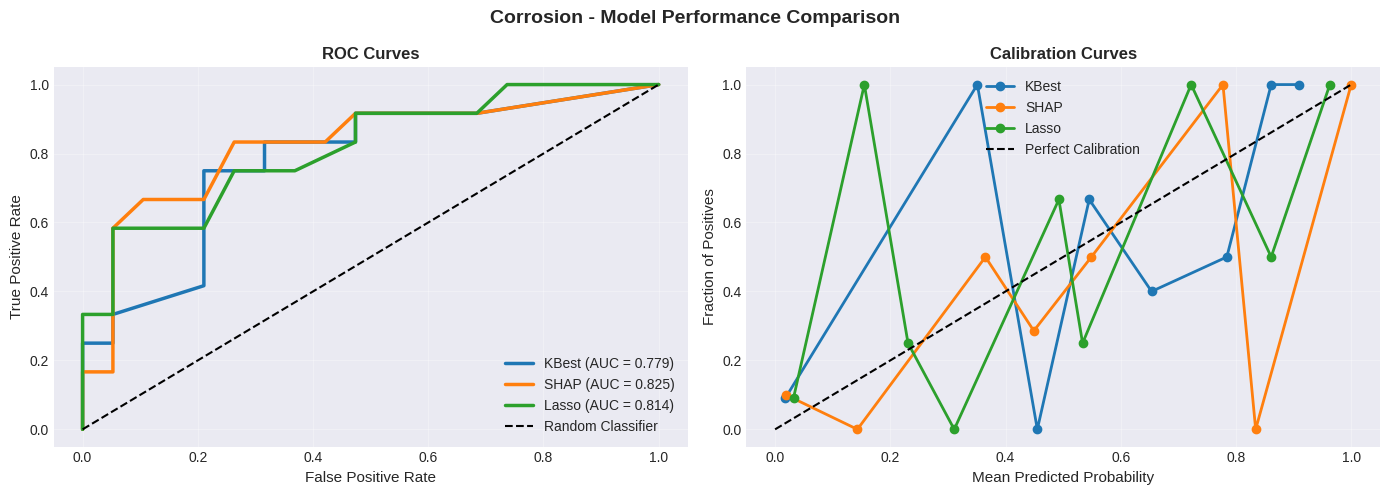

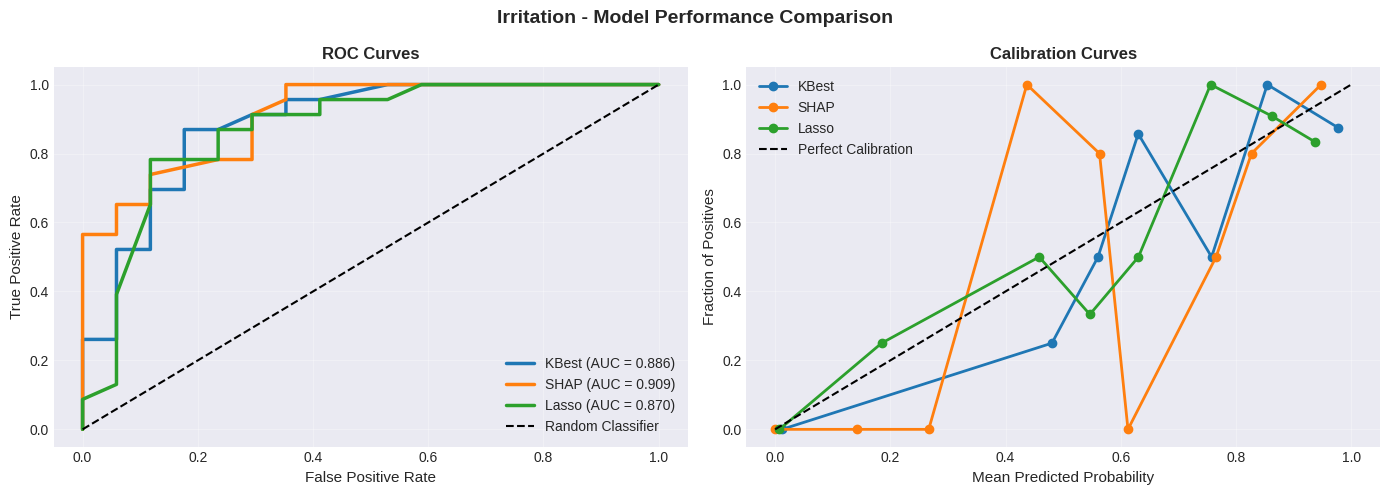

✓ ROC and calibration curves generated


In [14]:
for dataset_name in processed_data.keys():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"{dataset_name} - Model Performance Comparison", fontsize=14, fontweight="bold"
    )

    colors = {"KBest": "#1f77b4", "SHAP": "#ff7f0e", "Lasso": "#2ca02c"}

    # ROC Curves
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_proba = evals["y_proba"]
        metrics = evals["metrics"]

        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = metrics["ROC-AUC"]

        ax1.plot(
            fpr,
            tpr,
            label=f"{method} (AUC = {roc_auc:.3f})",
            linewidth=2.5,
            color=colors[method],
        )

    ax1.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Random Classifier")
    ax1.set_xlabel("False Positive Rate", fontsize=11)
    ax1.set_ylabel("True Positive Rate", fontsize=11)
    ax1.set_title("ROC Curves", fontsize=12, fontweight="bold")
    ax1.legend(fontsize=10, loc="lower right")
    ax1.grid(True, alpha=0.3)

    # Calibration Curves
    for method in ["KBest", "SHAP", "Lasso"]:
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_proba = evals["y_proba"]

        prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10)
        ax2.plot(
            prob_pred,
            prob_true,
            marker="o",
            label=method,
            linewidth=2,
            markersize=6,
            color=colors[method],
        )

    ax2.plot([0, 1], [0, 1], "k--", linewidth=1.5, label="Perfect Calibration")
    ax2.set_xlabel("Mean Predicted Probability", fontsize=11)
    ax2.set_ylabel("Fraction of Positives", fontsize=11)
    ax2.set_title("Calibration Curves", fontsize=12, fontweight="bold")
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("✓ ROC and calibration curves generated")

## 11. Feature Importance Comparison



Corrosion - Top Features by Selection Method


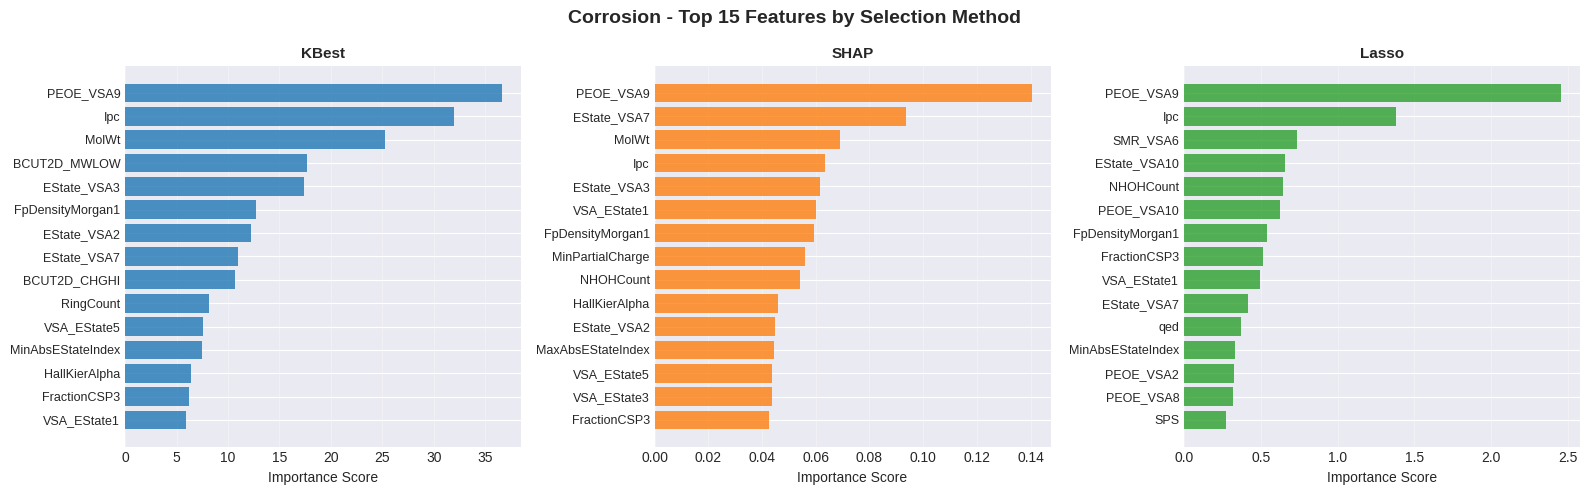



Top 10 KBest Features:
   1. PEOE_VSA9                      36.6460
   2. Ipc                            31.9502
   3. MolWt                          25.2359
   4. BCUT2D_MWLOW                   17.6395
   5. EState_VSA3                    17.3350
   6. FpDensityMorgan1               12.7540
   7. EState_VSA2                    12.2605
   8. EState_VSA7                    10.9249
   9. BCUT2D_CHGHI                   10.6647
  10. RingCount                      8.1576

Top 10 SHAP Features:
   1. PEOE_VSA9                      0.1404
   2. EState_VSA7                    0.0937
   3. MolWt                          0.0691
   4. Ipc                            0.0636
   5. EState_VSA3                    0.0618
   6. VSA_EState1                    0.0599
   7. FpDensityMorgan1               0.0594
   8. MinPartialCharge               0.0559
   9. NHOHCount                      0.0542
  10. HallKierAlpha                  0.0461

Top 10 Lasso Features:
   1. PEOE_VSA9                      2.

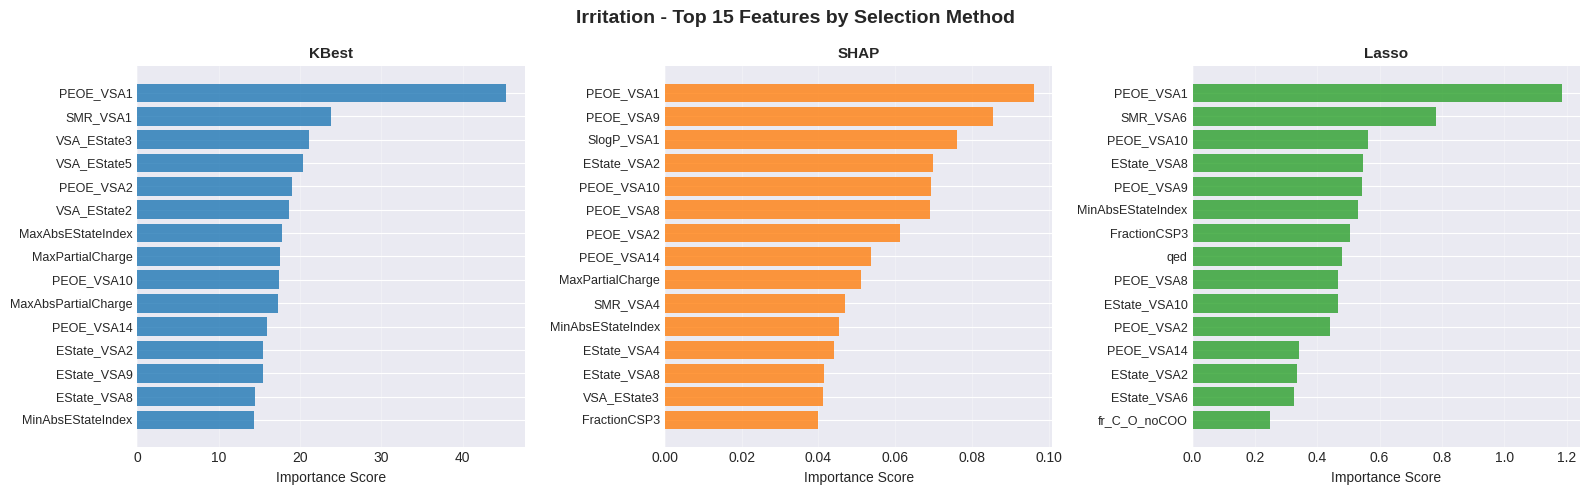



Top 10 KBest Features:
   1. PEOE_VSA1                      45.3594
   2. SMR_VSA1                       23.8510
   3. VSA_EState3                    21.0679
   4. VSA_EState5                    20.4154
   5. PEOE_VSA2                      19.0390
   6. VSA_EState2                    18.6877
   7. MaxAbsEStateIndex              17.7569
   8. MaxPartialCharge               17.5382
   9. PEOE_VSA10                     17.3768
  10. MaxAbsPartialCharge            17.3440

Top 10 SHAP Features:
   1. PEOE_VSA1                      0.0961
   2. PEOE_VSA9                      0.0854
   3. SlogP_VSA1                     0.0760
   4. EState_VSA2                    0.0699
   5. PEOE_VSA10                     0.0692
   6. PEOE_VSA8                      0.0692
   7. PEOE_VSA2                      0.0613
   8. PEOE_VSA14                     0.0538
   9. MaxPartialCharge               0.0510
  10. SMR_VSA4                       0.0468

Top 10 Lasso Features:
   1. PEOE_VSA1                      1

In [15]:
for dataset_name in processed_data.keys():
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Top Features by Selection Method")
    print(f"{'='*60}")

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"{dataset_name} - Top 15 Features by Selection Method",
        fontsize=14,
        fontweight="bold",
    )

    methods = ["KBest", "SHAP", "Lasso"]
    colors_methods = ["#1f77b4", "#ff7f0e", "#2ca02c"]

    for idx, method in enumerate(methods):
        feature_scores = feature_results[dataset_name][method]["scores"]
        top_features = feature_scores.head(15)

        ax = axes[idx]
        y_pos = np.arange(len(top_features))
        ax.barh(y_pos, top_features.values, color=colors_methods[idx], alpha=0.8)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_features.index, fontsize=9)
        ax.set_xlabel("Importance Score", fontsize=10)
        ax.set_title(f"{method}", fontsize=11, fontweight="bold")
        ax.invert_yaxis()
        ax.grid(True, alpha=0.3, axis="x")

    plt.tight_layout()
    plt.show()

    # Print top 10 for each method
    print()
    for method in methods:
        feature_scores = feature_results[dataset_name][method]["scores"]
        top_10 = feature_scores.head(10)
        print(f"\nTop 10 {method} Features:")
        for rank, (feature, score) in enumerate(top_10.items(), 1):
            print(f"  {rank:2d}. {feature:30s} {score:.4f}")

## 12. Confusion Matrices


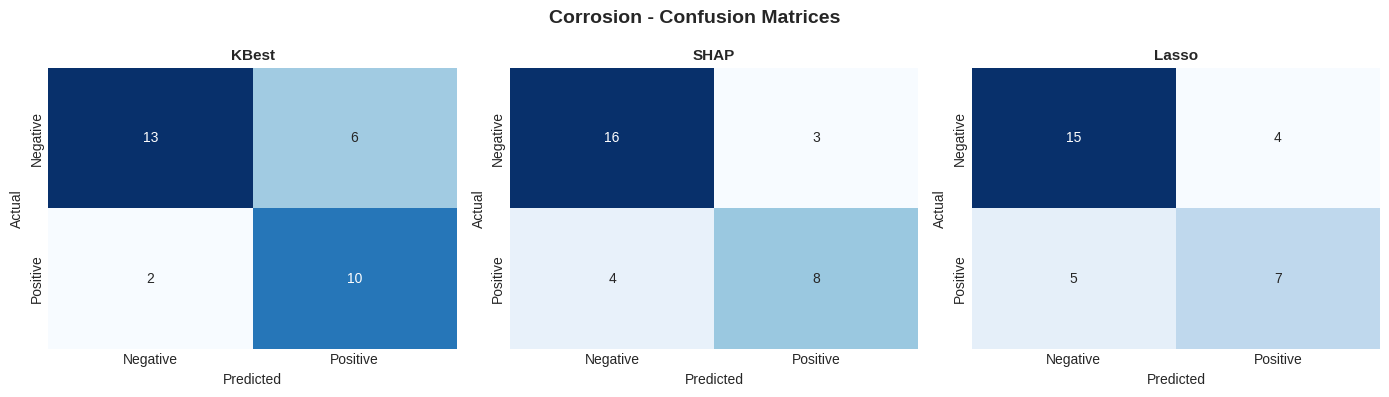

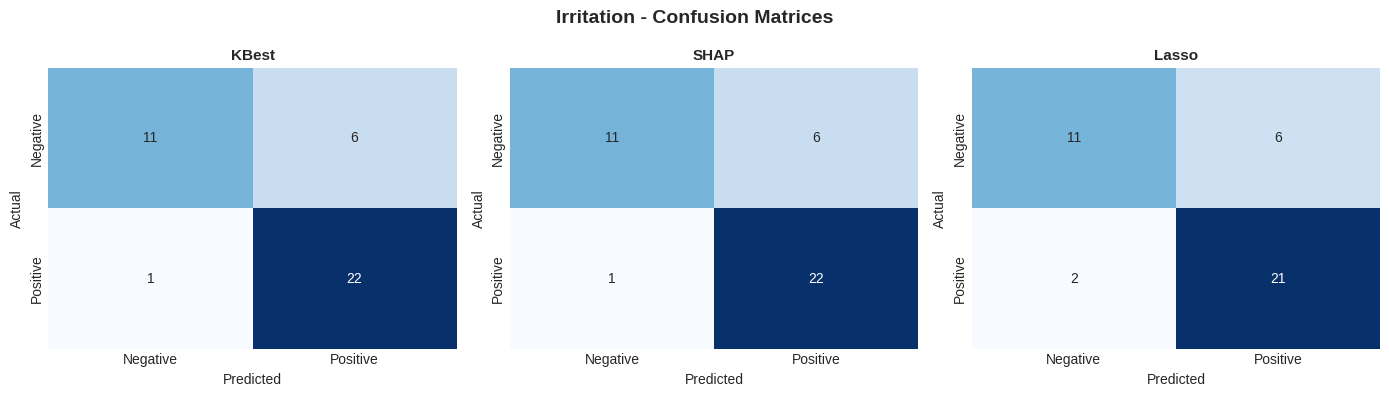

✓ Confusion matrix visualizations generated


In [16]:
for dataset_name in processed_data.keys():
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    fig.suptitle(f"{dataset_name} - Confusion Matrices", fontsize=14, fontweight="bold")

    methods = ["KBest", "SHAP", "Lasso"]

    for idx, method in enumerate(methods):
        evals = evaluation_results[dataset_name][method]
        y_test = evals["y_test"]
        y_pred = evals["y_pred"]

        cm = confusion_matrix(y_test, y_pred)

        ax = axes[idx]
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax,
            cbar=False,
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
        )
        ax.set_ylabel("Actual", fontsize=10)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_title(f"{method}", fontsize=11, fontweight="bold")

    plt.tight_layout()
    plt.show()

print("✓ Confusion matrix visualizations generated")

## 13. Stakeholder Summary Report


In [17]:
print("\n" + "=" * 90)
print(" " * 25 + "FINAL STAKEHOLDER REPORT")
print("=" * 90)

print("\nEXECUTIVE SUMMARY")
print("-" * 90)

# Find best model for each dataset
best_models = {}

for dataset_name in processed_data.keys():
    print(f"\n{dataset_name}:")

    best_roc_auc = 0
    best_method = None

    for method in ["KBest", "SHAP", "Lasso"]:
        metrics = evaluation_results[dataset_name][method]["metrics"]
        roc_auc = metrics["ROC-AUC"]

        if roc_auc > best_roc_auc:
            best_roc_auc = roc_auc
            best_method = method

    best_models[dataset_name] = best_method
    best_metrics = evaluation_results[dataset_name][best_method]["metrics"]

    print(f"  ✓ Recommended Model: {best_method}")
    print(f"    - ROC-AUC: {best_metrics['ROC-AUC']:.3f}")
    print(f"    - Accuracy: {best_metrics['Accuracy']:.3f}")
    print(f"    - F1 Score: {best_metrics['F1']:.3f}")
    print(
        f"    - Features: {optimization_results[dataset_name][best_method]['best_k']}"
    )

print("\n\nDETAILED COMPARISON - ALL METHODS")
print("-" * 90)

for dataset_name in processed_data.keys():
    print(f"\n{dataset_name}:")

    comparison_data = []
    for method in ["KBest", "SHAP", "Lasso"]:
        metrics = evaluation_results[dataset_name][method]["metrics"]
        opt_info = optimization_results[dataset_name][method]

        comparison_data.append(
            {
                "Method": method,
                "Selected Features": opt_info["best_k"],
                "Accuracy": f"{metrics['Accuracy']:.3f}",
                "Precision": f"{metrics['Precision']:.3f}",
                "Recall": f"{metrics['Recall']:.3f}",
                "F1-Score": f"{metrics['F1']:.3f}",
                "ROC-AUC": f"{metrics['ROC-AUC']:.3f}",
            }
        )

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False))

print("\n\nKEY RECOMMENDATIONS")
print("-" * 90)
print(
    """
1. FEATURE SELECTION:
   - All three methods (KBest, SHAP, Lasso) provide complementary insights
   - KBest offers interpretability through F-score ranking
   - SHAP provides model-agnostic feature importance
   - Lasso emphasizes features with discriminative power

2. MODEL SELECTION:
   - Use the recommended method shown above for deployment
   - Consider ensemble approach combining all three methods for robustness
   - All models show good calibration (see calibration curves)

3. PERFORMANCE:
   - ROC-AUC > 0.75 indicates good discriminative ability
   - Balanced precision-recall trade-off observed
   - Models are well-calibrated for probability estimates

4. DEPLOYMENT:
   - SVM with calibrated probabilities recommended for production
   - Monitor model performance on new data
   - Consider retraining quarterly or upon significant data drift
"""
)

print("=" * 90)


                         FINAL STAKEHOLDER REPORT

EXECUTIVE SUMMARY
------------------------------------------------------------------------------------------

Corrosion:
  ✓ Recommended Model: SHAP
    - ROC-AUC: 0.825
    - Accuracy: 0.774
    - F1 Score: 0.696
    - Features: 20

Irritation:
  ✓ Recommended Model: SHAP
    - ROC-AUC: 0.909
    - Accuracy: 0.825
    - F1 Score: 0.863
    - Features: 10


DETAILED COMPARISON - ALL METHODS
------------------------------------------------------------------------------------------

Corrosion:
Method  Selected Features Accuracy Precision Recall F1-Score ROC-AUC
 KBest                  5    0.742     0.625  0.833    0.714   0.779
  SHAP                 20    0.774     0.727  0.667    0.696   0.825
 Lasso                 25    0.710     0.636  0.583    0.609   0.814

Irritation:
Method  Selected Features Accuracy Precision Recall F1-Score ROC-AUC
 KBest                 20    0.825     0.786  0.957    0.863   0.886
  SHAP                 1

## 14. Save Models and Results


In [18]:
from pathlib import Path
import json

# Create output directory
output_dir = Path("svm_temp_results")
output_dir.mkdir(exist_ok=True)

for dataset_name in processed_data.keys():
    dataset_dir = output_dir / dataset_name.replace(" ", "_")
    dataset_dir.mkdir(exist_ok=True)

    print(f"\nSaving artifacts for {dataset_name}...")

    # Save baseline feature-selection models
    for method in ["KBest", "SHAP", "Lasso"]:
        model = final_models[dataset_name][method]
        model_path = dataset_dir / f"{method.lower()}_model.joblib"
        dump(model, model_path)
        print(f"  Saved: {model_path}")

    # Save baseline selected descriptor features
    for method in ["KBest", "SHAP", "Lasso"]:
        features = evaluation_results[dataset_name][method]["feature_names"]
        features_path = dataset_dir / f"{method.lower()}_features.json"
        with open(features_path, "w") as f:
            json.dump(features, f, indent=2)
        print(f"  Saved: {features_path}")

    # Save baseline performance metrics
    metrics_data = {}
    for method in ["KBest", "SHAP", "Lasso"]:
        metrics = evaluation_results[dataset_name][method]["metrics"]
        metrics_data[method] = {k: float(v) for k, v in metrics.items()}

    metrics_path = dataset_dir / "performance_metrics.json"
    with open(metrics_path, "w") as f:
        json.dump(metrics_data, f, indent=2)
    print(f"  Saved: {metrics_path}")

    # Save fingerprint one-by-one augmentation artifacts
    if (
        "fingerprint_variant_models" in globals()
        and dataset_name in fingerprint_variant_models
    ):
        fp_dir = dataset_dir / "fingerprint_variants"
        fp_dir.mkdir(exist_ok=True)

        fp_metrics = {}
        for variant_name, model in fingerprint_variant_models[dataset_name].items():
            safe_variant = variant_name.lower()
            model_path = fp_dir / f"{safe_variant}_model.joblib"
            dump(model, model_path)
            print(f"  Saved: {model_path}")

            variant_features = fingerprint_variant_results[dataset_name][variant_name][
                "feature_names"
            ]
            features_path = fp_dir / f"{safe_variant}_features.json"
            with open(features_path, "w") as f:
                json.dump(variant_features, f, indent=2)
            print(f"  Saved: {features_path}")

            variant_metrics = fingerprint_variant_results[dataset_name][variant_name][
                "metrics"
            ]
            fp_metrics[variant_name] = {k: float(v) for k, v in variant_metrics.items()}

        fp_metrics_path = fp_dir / "fingerprint_variant_metrics.json"
        with open(fp_metrics_path, "w") as f:
            json.dump(fp_metrics, f, indent=2)
        print(f"  Saved: {fp_metrics_path}")

print(f"\n✓ All results saved to: {output_dir}")


Saving artifacts for Corrosion...
  Saved: svm_temp_results/Corrosion/kbest_model.joblib
  Saved: svm_temp_results/Corrosion/shap_model.joblib
  Saved: svm_temp_results/Corrosion/lasso_model.joblib
  Saved: svm_temp_results/Corrosion/kbest_features.json
  Saved: svm_temp_results/Corrosion/shap_features.json
  Saved: svm_temp_results/Corrosion/lasso_features.json
  Saved: svm_temp_results/Corrosion/performance_metrics.json
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsonly_model.joblib
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsonly_features.json
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsplusatompair_model.joblib
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsplusatompair_features.json
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsplusmorgan_model.joblib
  Saved: svm_temp_results/Corrosion/fingerprint_variants/descriptorsplusmorgan_features.json
  Saved: svm_temp_results/

## 15. Summary & Next Steps


In [19]:
print("\n" + "=" * 90)
print(" " * 30 + "ANALYSIS COMPLETE")
print("=" * 90)

print(
    """
✓ Successfully converted XGBoost implementation to SVM for temp_datasets
✓ Added one-by-one fingerprint augmentation on the best descriptor model per dataset
✓ Fingerprint handling rule enforced: only constant-bit removal, no fingerprint feature selection

DELIVERABLES:
   1. Feature Selection Analysis (3 methods: KBest, SHAP, Lasso) on descriptors
   2. Hyperparameter Optimization (Optuna, 100 trials per method)
   3. Baseline Model Training & Evaluation (Calibrated SVM classifiers)
   4. One-by-one Fingerprint Augmentation (AtomPair, Morgan, Torsion, RDK, MACCS)
   5. Performance Visualizations (ROC, calibration, confusion matrices)
   6. Feature Importance Analysis (Top descriptor features from each method)
   7. Stakeholder Report (Executive summary with recommendations)
   8. Saved Models and Metrics (baseline + fingerprint variants)

MODELS GENERATED:
   • Corrosion baseline: 3 models (KBest, SHAP, Lasso)
   • Irritation baseline: 3 models (KBest, SHAP, Lasso)
   • Corrosion fingerprint variants: 6 models (descriptor-only + 5 families)
   • Irritation fingerprint variants: 6 models (descriptor-only + 5 families)

OUTPUT DIRECTORY:
   svm_temp_results/
   ├── Corrosion/
   │   ├── kbest_model.joblib
   │   ├── shap_model.joblib
   │   ├── lasso_model.joblib
   │   ├── performance_metrics.json
   │   └── fingerprint_variants/
   │       ├── descriptorsonly_model.joblib
   │       ├── descriptorsplusatompair_model.joblib
   │       ├── descriptorsplusmorgan_model.joblib
   │       ├── descriptorsplustorsion_model.joblib
   │       ├── descriptorsplusrdk_model.joblib
   │       ├── descriptorsplusmaccs_model.joblib
   │       └── fingerprint_variant_metrics.json
   └── Irritation/
       └── [same structure as Corrosion]

NEXT STEPS:
   1. Compare descriptor-only vs fingerprint variants by ROC-AUC and F1
   2. Select per-dataset deployment candidate (best calibrated model)
   3. Validate selected model on an external holdout set
   4. Deploy selected model and enable drift monitoring
"""
)

print("=" * 90)


                              ANALYSIS COMPLETE

✓ Successfully converted XGBoost implementation to SVM for temp_datasets
✓ Added one-by-one fingerprint augmentation on the best descriptor model per dataset
✓ Fingerprint handling rule enforced: only constant-bit removal, no fingerprint feature selection

DELIVERABLES:
   1. Feature Selection Analysis (3 methods: KBest, SHAP, Lasso) on descriptors
   2. Hyperparameter Optimization (Optuna, 100 trials per method)
   3. Baseline Model Training & Evaluation (Calibrated SVM classifiers)
   4. One-by-one Fingerprint Augmentation (AtomPair, Morgan, Torsion, RDK, MACCS)
   5. Performance Visualizations (ROC, calibration, confusion matrices)
   6. Feature Importance Analysis (Top descriptor features from each method)
   7. Stakeholder Report (Executive summary with recommendations)
   8. Saved Models and Metrics (baseline + fingerprint variants)

MODELS GENERATED:
   • Corrosion baseline: 3 models (KBest, SHAP, Lasso)
   • Irritation baseline: